# **BIGMART SALES**

# **1. Business Problem Understanding**

**Context**

BigMart merupakan jaringan ritel berskala besar yang beroperasi di berbagai lokasi dengan beragam karakteristik outlet serta ribuan jenis produk. Dalam operasionalnya, BigMart menghadapi tantangan dalam memahami pola penjualan yang sangat bervariasi antar-outlet maupun antar-produk. Perbedaan atribut produk seperti Item Type, Item MRP, Item Weight, Fat Content, hingga Visibility, ditambah variasi pada karakteristik outlet seperti Outlet Type, Outlet Size, Outlet Location, dan Outlet Establishment Year, membuat penjualan sulit diprediksi secara intuitif. Ketidakmampuan perusahaan dalam memperkirakan permintaan dengan akurat berpotensi menyebabkan overstock, out-of-stock, serta inefisiensi biaya distribusi dan penyimpanan. Hal ini menurunkan pendapatan sekaligus meningkatkan biaya operasional.

**Problem Statement**

Meskipun data penjualan produk telah tersedia, BigMart belum memiliki model analitik yang mampu memprediksi Item Outlet Sales secara akurat. Perusahaan juga belum memahami variabel mana yang paling memengaruhi penjualan di setiap outlet. Ketiadaan insight ini membuat strategi stok, harga, dan display produk tidak optimal.

**Project Goals**

Tujuan utama proyek ini adalah melakukan eksplorasi data untuk memahami pola penjualan, distribusi variabel, serta faktor-faktor yang memengaruhi performa produk dan juga membangun model prediksi yang dapat memperkirakan nilai penjualan setiap produk di tiap outlet. Dengan model ini, BigMart dapat mengoptimalkan manajemen inventori, menentukan strategi harga yang lebih tepat, memperbaiki penempatan produk di rak, serta menghasilkan keputusan bisnis yang lebih berbasis data.

**Data Understanding**

* Item_Identifier: kode unik untuk setiap produk (categorical).

* Item_Weight: berat produk dalam kilogram (numeric).

* Item_Fat_Content: kategori kandungan lemak produk, seperti Low Fat, Regular, dan beberapa variasi penulisan lain (categorical).

* Item_Visibility: persentase visibilitas produk di rak toko (numeric).

* Item_Type: jenis atau kategori produk, seperti dairy, snacks, beverages, household, dll. (categorical).

* Item_MRP: harga maksimum retail produk (numeric).

* Outlet_Identifier: kode unik untuk setiap outlet (categorical).

* Outlet_Establishment_Year: tahun outlet dibangun (numeric).

* Outlet_Size: ukuran outlet, seperti Small, Medium, Large (categorical).

* Outlet_Location_Type: tipe lokasi outlet, seperti Tier 1, Tier 2, Tier 3 (categorical).

* Outlet_Type: jenis outlet, seperti Supermarket Type1, Type2, Type3, atau Grocery Store (categorical).

* Item_Outlet_Sales: jumlah penjualan produk pada outlet tertentu; ini merupakan variabel target yang akan diprediksi (numeric).

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **2. Load Dataset**

In [3]:
df = pd.read_csv('Train.csv',sep=',')

In [4]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


# **3. Overview Data**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [7]:
#Numerical statistical summary
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [8]:
#Categorical statistical summary
df.describe(include=object)

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


# **4. Data Cleaning**

**Check Missing Value**

In [9]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

**Terdapat Missing Value pada 2 variabel yaitu Item_Weight dan Outlet_Size**

**Handling Missing Value**

In [10]:
# Cek persentase missing
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

Item_Identifier               0.000000
Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64

**Dari hasil perhitungan, terlihat bahwa jumlah missing value pada dataset masih berada pada tingkat yang tidak terlalu tinggi yaitu 17% dan 28%, sehingga lebih baik dilakukan imputasi daripada menghapus baris atau kolom. Penghapusan data dapat menyebabkan data loss, menghilangkan informasi penting (seperti kategori item, harga, lokasi outlet), serta berpotensi menurunkan performa model.**

Impute Missing Value Item_Weight

In [11]:
# Hitung rata-rata berat per Item_Identifier
item_weight_mean = df.groupby('Item_Identifier')['Item_Weight'].mean()

# Isi missing value berdasarkan mean tiap item
df['Item_Weight'] = df.apply(
    lambda row: item_weight_mean[row['Item_Identifier']] 
                if pd.isna(row['Item_Weight']) else row['Item_Weight'],
    axis=1
)

# Jika masih ada missing (fallback), isi dengan median global
df['Item_Weight'].fillna(df['Item_Weight'].median(), inplace=True)



untuk variabel Item_Weight ini kami tidak mengisi dengan mean/median global karena setiap Item_Identifier memiliki berat khas masing-masing. Mengisi semua missing value dengan satu angka global akan merusak karakter produk.
Sebagai contoh, Item A biasanya memiliki berat sekitar 9–10 kg, sedangkan Item B berada di 5–6 kg. Kalau kita isi dengan median global (misalnya 7.8 kg), maka nilai tersebut tidak cocok untuk kedua item tersebut.
Karena itu, imputasi dilakukan menggunakan median per Item_Identifier agar nilai yang hilang tetap sesuai dengan karakter produk aslinya.

Impute Missing Value Outlet_Size

In [12]:
# Mode (nilai paling sering muncul) per Outlet_Type
outlet_size_mode = df.groupby('Outlet_Type')['Outlet_Size'].agg(lambda x: x.mode()[0])

# Isi missing berdasarkan mode tiap Outlet_Type
df['Outlet_Size'] = df.apply(
    lambda row: outlet_size_mode[row['Outlet_Type']] 
                if pd.isna(row['Outlet_Size']) else row['Outlet_Size'],
    axis=1
)

sedangkan untuk variabel Outlet_Size ini kami tidak mengisinya dengan modus keseluruhan karena ukuran outlet berbeda-beda tergantung jenis outletnya. Setiap Outlet_Type memiliki pola ukuran yang konsisten (misalnya Grocery Store cenderung Small, Supermarket lebih besar). Karena itu, imputasi dilakukan berdasarkan modus per Outlet_Type agar hasilnya lebih akurat dan tidak merusak pola asli data.

In [13]:
df.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


**Check Duplicate Data**

In [15]:
df.duplicated().sum()

0

Tidak ada data yang duplicate

**Check Inconsisten Data**

In [16]:
for col in df.columns:
    print(f"Unique values in column '{col}':")
    print(df[col].unique())
    print("\n")

Unique values in column 'Item_Identifier':
['FDA15' 'DRC01' 'FDN15' ... 'NCF55' 'NCW30' 'NCW05']


Unique values in column 'Item_Weight':
[ 9.3    5.92  17.5   19.2    8.93  10.395 13.65  19.    16.2   11.8
 18.5   15.1   17.6   16.35   9.     8.26  13.35  18.85   8.315 14.6
 15.5   13.85  13.     7.645 11.65   5.925 14.5   19.25  18.6   18.7
 17.85  10.    20.2    8.85   6.385 15.25   9.8   13.6   21.35  12.15
  6.42  19.6   15.85  10.195  7.39   9.895 10.895  7.905  9.195  8.365
  5.94   7.97   6.215 17.7   19.35   8.645 15.6   18.25   7.855  7.825
  8.39  12.85   5.905  7.76  16.75  12.6    6.055  6.305 20.85  20.75
  8.895 19.7    7.93   8.75  13.3   20.6    8.31  19.75  17.1   10.5
  6.635  9.395 14.15   8.89   6.69   6.195  9.1    7.5   16.85   7.485
 11.6   12.65  20.25   8.6    8.88  20.5   12.    13.5    7.235  6.92
  8.02  12.8   16.6   14.    16.    21.25   9.5    7.365 18.35   5.465
  7.27   6.155 19.5   15.2   13.1   12.3   11.1   11.3    5.75  11.35
  6.525 10.3    5.78  

In [17]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [18]:
df['Item_Visibility'].value_counts()

Item_Visibility
0.000000    526
0.076975      3
0.162462      2
0.076841      2
0.073562      2
           ... 
0.013957      1
0.110460      1
0.124646      1
0.054142      1
0.044878      1
Name: count, Length: 7880, dtype: int64

**Terdapat data yang tidak konsisten pada variabel Item_Fat_Content
dan juga ada data yang tidak masuk akal pada variabel Item_visibility karena setiap barang di suatu supermarket itu pasti memiliki nilainya
karena pasti setiap barang yang ada di supermarket pasti di tampilkan**

Solusi:

* Perbaiki ketidak konsiten data pada variabel Item_Fat_Content

* nilai 0 pada vaiabel Item_Visibility diganti dengan median visibility per Item_Identifier, supaya tetap sesuai karakter masing-masing item. seperti kasus isi missing value

In [19]:
# Ganti value yg tidak konsisten di Item_Fat_Content
df['Item_Fat_Content'].replace('LF','Low Fat', inplace=True)
df['Item_Fat_Content'].replace('low fat','Low Fat', inplace=True)
df['Item_Fat_Content'].replace('reg','Regular', inplace=True)

In [20]:
# 1. Hitung median visibility per item
item_visibility_median = df.groupby("Item_Identifier")["Item_Visibility"].median()
# 2. Ganti nilai 0 dengan median berdasarkan item
df["Item_Visibility"] = df.apply(
    lambda row: item_visibility_median[row["Item_Identifier"]]
    if row["Item_Visibility"] == 0
    else row["Item_Visibility"],
    axis=1
)
# 3. Jika masih ada median item yg 0 (item jarang muncul), isi median global
df["Item_Visibility"].replace(0, df["Item_Visibility"].median(), inplace=True)

In [21]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [22]:
df['Item_Visibility'].value_counts()

Item_Visibility
0.057654    5
0.060603    4
0.079690    3
0.058486    3
0.081788    3
           ..
0.041429    1
0.026841    1
0.096930    1
0.040946    1
0.044878    1
Name: count, Length: 8086, dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


**Setelah proses Cleaning selesai kalian bisa liat kalau Variabel Item_Identifier tidak memberikan informasi yang relevan untuk proses pemodelan. Kolom ini hanya berfungsi sebagai kode unik produk dan tidak merepresentasikan karakteristik yang dapat membantu model dalam memprediksi penjualan. Selain itu, nilai di dalamnya sangat banyak dan bersifat high-cardinality; jika di-encode justru akan menghasilkan ratusan kolom baru yang tidak efisien dan dapat menyebabkan overfitting. Informasi penting mengenai produk sudah diwakili oleh atribut lain seperti Item_Type, Item_Weight, dan Item_MRP, sehingga Item_Identifier aman untuk dihapus.**

**kenapa kita tidak hapus di awal karena dia berguna untuk impute missing value**

**Outlet_Identifier juga bakal kita Drop karena sama saja halnya dengan Item_Identifier**

In [24]:
#hapus kolom item_identifier dan Outlet Identifier
df = df.drop(columns=['Item_Identifier','Outlet_Identifier'])


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Fat_Content           8523 non-null   object 
 2   Item_Visibility            8523 non-null   float64
 3   Item_Type                  8523 non-null   object 
 4   Item_MRP                   8523 non-null   float64
 5   Outlet_Establishment_Year  8523 non-null   int64  
 6   Outlet_Size                8523 non-null   object 
 7   Outlet_Location_Type       8523 non-null   object 
 8   Outlet_Type                8523 non-null   object 
 9   Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 666.0+ KB


**Tambahan**

Variabel Outlet_Establishment_Year tidak terlalu informatif jika dibiarkan dalam bentuk tahun berdiri.
Agar lebih berguna untuk analisis dan modeling, kolom tersebut diubah menjadi umur outlet, yaitu selisih antara tahun analisis dan tahun pendirian.

In [26]:
# tambahin variabel Outlet_Age
df['Outlet_Age'] = 2025  - df['Outlet_Establishment_Year']

In [27]:
# drop variabel Outlet_Estabilishment_Year
df.drop("Outlet_Establishment_Year", axis=1, inplace=True) 

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item_Weight           8523 non-null   float64
 1   Item_Fat_Content      8523 non-null   object 
 2   Item_Visibility       8523 non-null   float64
 3   Item_Type             8523 non-null   object 
 4   Item_MRP              8523 non-null   float64
 5   Outlet_Size           8523 non-null   object 
 6   Outlet_Location_Type  8523 non-null   object 
 7   Outlet_Type           8523 non-null   object 
 8   Item_Outlet_Sales     8523 non-null   float64
 9   Outlet_Age            8523 non-null   int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 666.0+ KB


In [29]:
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,9.30,Low Fat,0.016047,Dairy,249.8092,Medium,Tier 1,Supermarket Type1,3735.1380,26
1,5.92,Regular,0.019278,Soft Drinks,48.2692,Medium,Tier 3,Supermarket Type2,443.4228,16
2,17.50,Low Fat,0.016760,Meat,141.6180,Medium,Tier 1,Supermarket Type1,2097.2700,26
3,19.20,Regular,0.022861,Fruits and Vegetables,182.0950,Small,Tier 3,Grocery Store,732.3800,27
4,8.93,Low Fat,0.006590,Household,53.8614,High,Tier 3,Supermarket Type1,994.7052,38


# **5. Explanatory Data Analysis**

**Distribusi Target: Item_Outlet_Sales**

Mengecek apakah target skewed, ada outlier, dan bagaimana bentuk distribusinya.

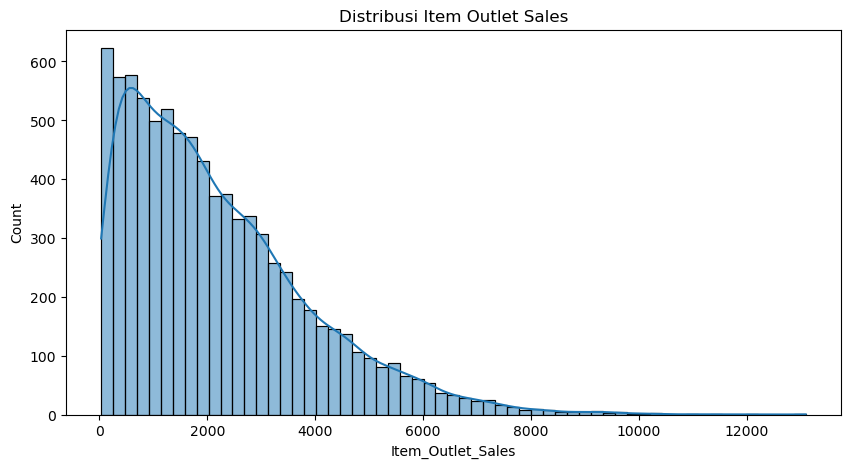

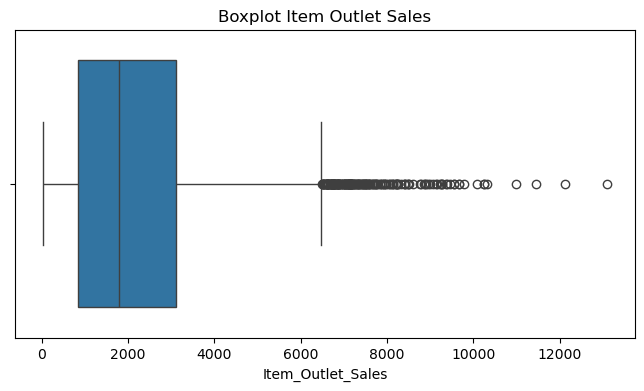

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(df["Item_Outlet_Sales"], kde=True)
plt.title("Distribusi Item Outlet Sales")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Item_Outlet_Sales"])
plt.title("Boxplot Item Outlet Sales")
plt.show()

**Distribusi Item_Outlet_Sales**

Distribusi penjualan terlihat right-skewed, di mana sebagian besar produk memiliki nilai penjualan rendah (0–4000), dan hanya sedikit produk yang mencapai penjualan sangat tinggi. Hal ini menunjukkan bahwa data target bersifat tidak normal dan memiliki variasi yang besar antar produk. sehingga nantinya saat modelling akan butuh normalisasi untuk hasil lebih stabil lagi

**Boxplot Item_Outlet_Sales**

Boxplot menunjukkan adanya banyak outlier (nilai penjualan ekstrem di sisi kanan). Outlier ini wajar dalam konteks data ritel karena beberapa produk atau outlet memang memiliki volume penjualan jauh lebih tinggi dibanding produk lainnya. Outlier tidak dihapus karena dapat mengandung informasi penting bagi model.

***Analisis Univariate Variabel Numerik***

1. Item Weight

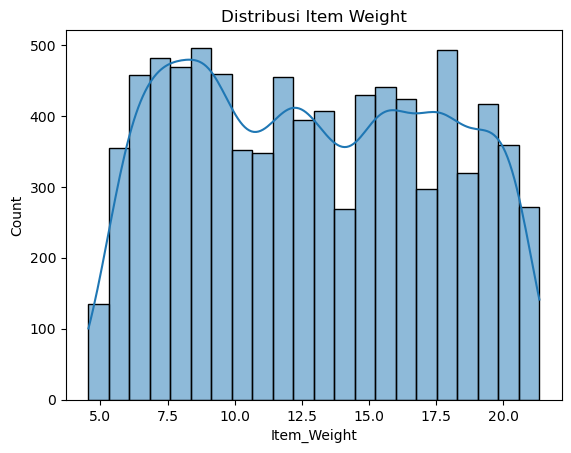

In [31]:
sns.histplot(df["Item_Weight"], kde=True)
plt.title("Distribusi Item Weight")
plt.show()

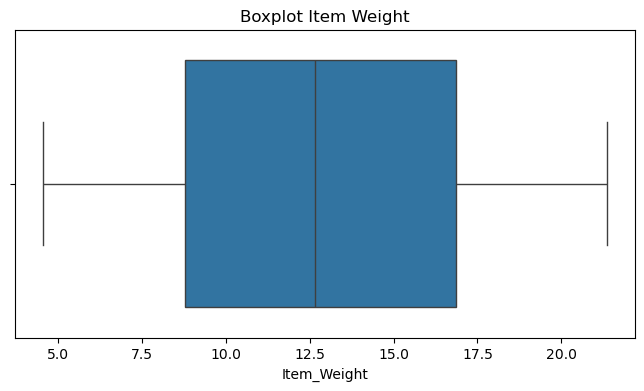

In [32]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Item_Weight"])
plt.title("Boxplot Item Weight")
plt.show()

**Distribusi Item_Weight terlihat relatif merata tanpa pola tertentu yang dominan. Tidak ada nilai ekstrem (outlier) yang mencolok, dan rentang berat barang tersebar cukup stabil dari nilai rendah hingga tinggi. Pola ini menunjukkan bahwa variasi berat produk dalam dataset cukup seimbang dan tidak menimbulkan indikasi anomali.**

2. Item_Visibility

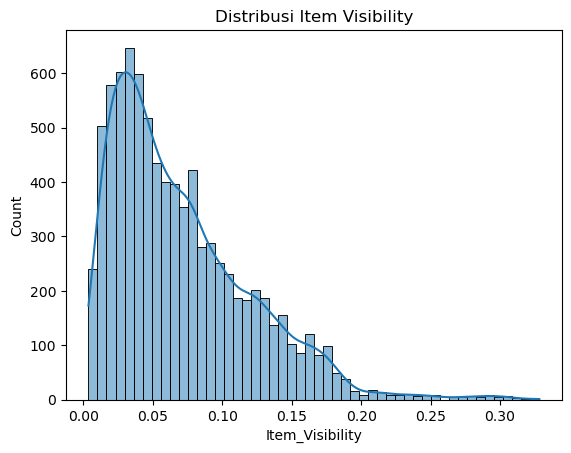

In [33]:
sns.histplot(df["Item_Visibility"], kde=True)
plt.title("Distribusi Item Visibility")
plt.show()

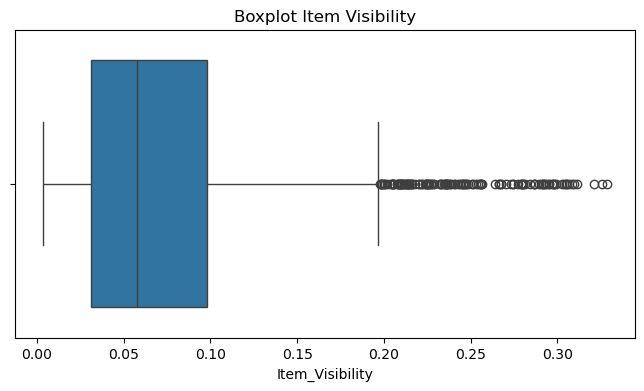

In [34]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Item_Visibility"])
plt.title("Boxplot Item Visibility")
plt.show()

**Distribusi Item_Visibility tampak sangat right-skewed, di mana sebagian besar produk memiliki visibilitas rendah. Terdapat beberapa nilai ekstrem (outlier) pada visibilitas yang tinggi, namun kemunculannya wajar karena hanya sebagian produk yang mendapatkan paparan atau penempatan yang lebih dominan di toko. Outlier ini tidak perlu dihapus, karena justru merepresentasikan kondisi nyata variasi visibilitas di lapangan.**

3. Item_MRP

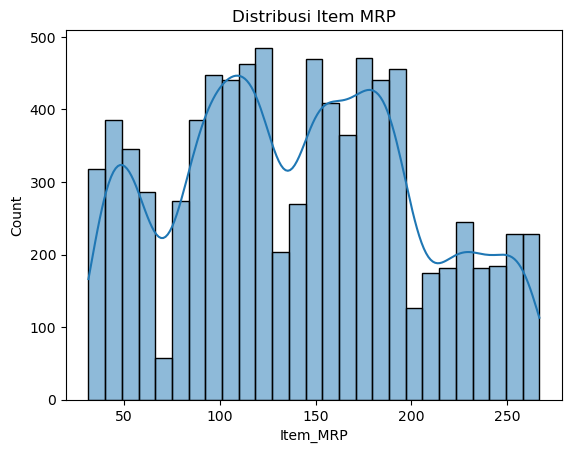

In [35]:
sns.histplot(df["Item_MRP"], kde=True)
plt.title("Distribusi Item MRP")
plt.show()

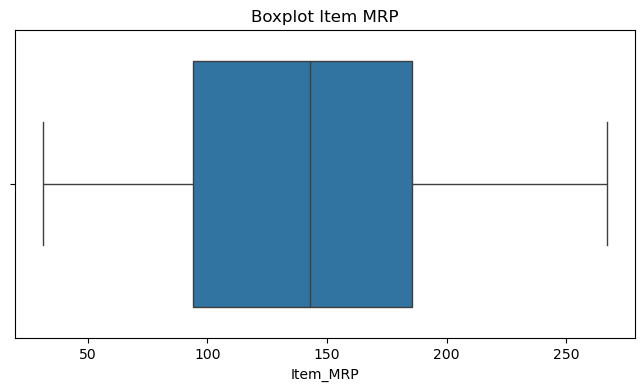

In [36]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Item_MRP"])
plt.title("Boxplot Item MRP")
plt.show()

**Distribusi Item_MRP terlihat multimodal, artinya terdapat beberapa kelompok harga yang umum muncul (beberapa puncak pada histogram). Hal ini wajar karena produk biasanya dikategorikan dalam range harga tertentu. Pada variabel ini tidak terlihat outlier ekstrem, dan nilai yang menyebar lebar justru mencerminkan variasi harga antar produk. Oleh karena itu, tidak diperlukan penanganan outlier**

4. Outlet_Age

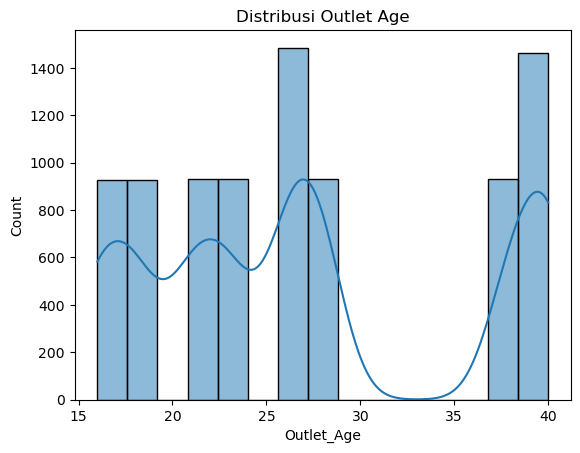

In [37]:
sns.histplot(df["Outlet_Age"], kde=True)
plt.title("Distribusi Outlet Age")
plt.show()

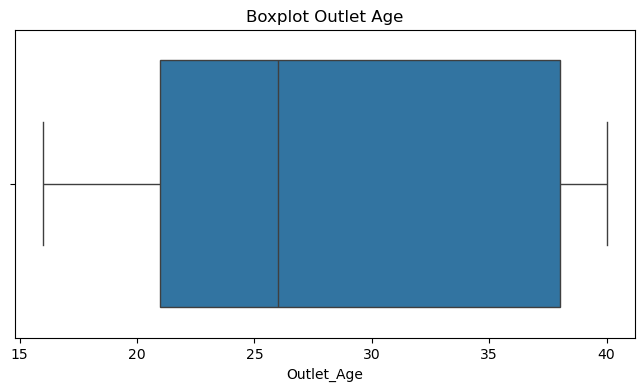

In [38]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Outlet_Age"])
plt.title("Boxplot Outlet Age")
plt.show()

**Distribusi Outlet_Age terlihat terdiri dari beberapa kelompok umur toko yang berbeda, menunjukkan bahwa pembukaan outlet terjadi pada beberapa periode tertentu. Polanya tampak clustered, bukan random. Nilainya berada pada rentang normal dan tidak ada outlier signifikan, karena umur outlet memang hanya berada dalam batas wajar berdasarkan tahun berdirinya. Variabel ini aman digunakan tanpa perlu perlakuan khusus terhadap outlier.**



***Analisis Univariate Variabel Kategorik***

1. Item Fat Content

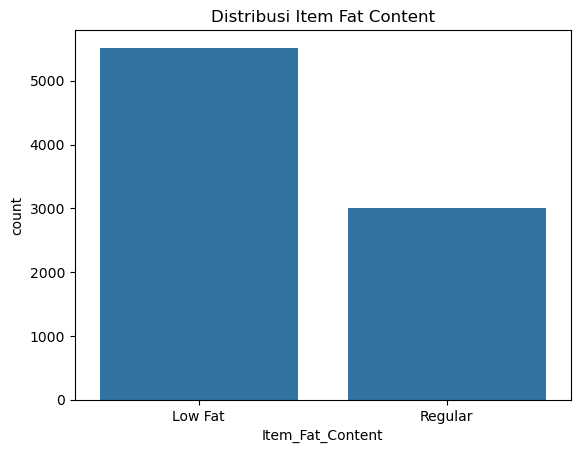

In [39]:
sns.countplot(x=df["Item_Fat_Content"])
plt.title("Distribusi Item Fat Content")
plt.show()

ini menunjukkan bahwa mayoritas produk termasuk dalam kategori Low Fat, sedangkan sisanya berada pada kategori Regular. Hal ini mengindikasikan bahwa produk rendah lemak lebih dominan dalam dataset, yang dapat mencerminkan preferensi konsumen terhadap produk yang dianggap lebih sehat.

2. Item Type

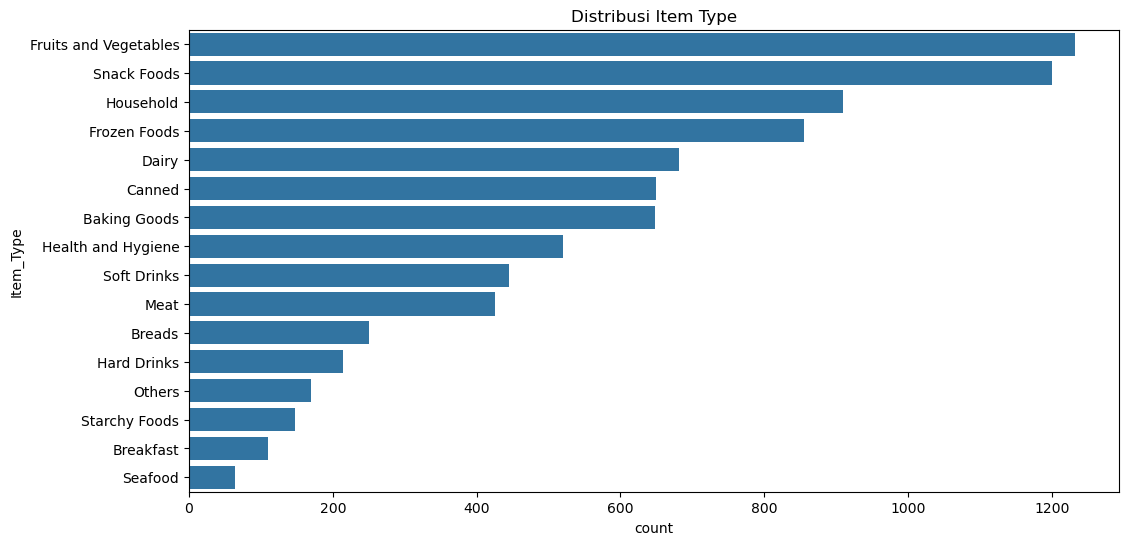

In [40]:
plt.figure(figsize=(12,6))
sns.countplot(y=df["Item_Type"], order=df["Item_Type"].value_counts().index)
plt.title("Distribusi Item Type")
plt.show()

ini menunjukkan bahwa kategori Fruits and Vegetables merupakan jenis produk yang paling banyak dijual, diikuti oleh Snack Foods dan Household. Sementara itu, kategori seperti Seafood, Breakfast, dan Starchy Foods memiliki jumlah yang relatif paling sedikit. Perbedaan ini menunjukkan ketimpangan distribusi antar jenis produk, sehingga perlu diperhatikan dalam tahap pemodelan agar tidak menimbulkan bias.

3. Outlet Type

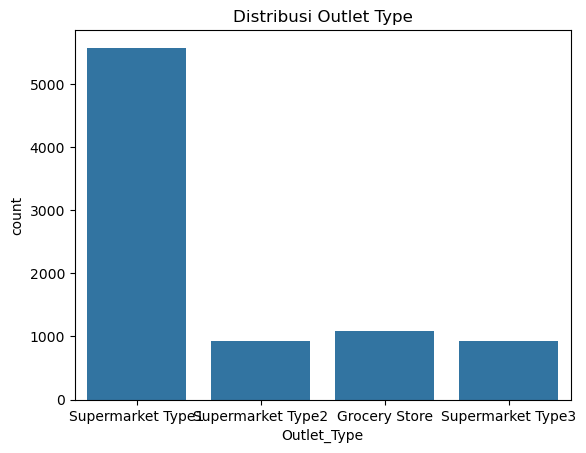

In [41]:
sns.countplot(x=df["Outlet_Type"])
plt.title("Distribusi Outlet Type")
plt.show()

ini menunjukkan bahwa Supermarket Type1 mendominasi jumlah outlet dalam dataset secara signifikan dibandingkan tipe outlet lainnya. Sementara itu, Grocery Store, Supermarket Type2, dan Supermarket Type3 memiliki jumlah yang relatif lebih sedikit dan cenderung seimbang satu sama lain. Ketimpangan ini mengindikasikan bahwa sebagian besar data penjualan berasal dari Supermarket Type1, sehingga tipe outlet ini berpotensi memiliki pengaruh besar terhadap target penjualan (Item_Outlet_Sales).

4. Outlet Location Type

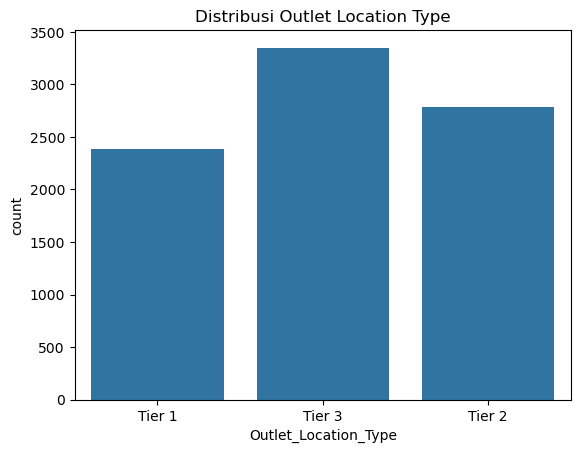

In [42]:
sns.countplot(x=df["Outlet_Location_Type"])
plt.title("Distribusi Outlet Location Type")
plt.show()

ini menunjukkan bahwa outlet dengan Location Type Tier 3 memiliki jumlah terbanyak, diikuti oleh Tier 2, dan Tier 1 sebagai yang paling sedikit. Hal ini menunjukkan bahwa outlet lebih banyak beroperasi di wilayah dengan klasifikasi Tier 3, yang kemungkinan merepresentasikan area dengan tingkat urbanisasi atau kepadatan tertentu. Variabel ini berpotensi memiliki hubungan terhadap performa penjualan dan layak dianalisis lebih lanjut pada tahap analisis bivariat.

5. Outlet Size

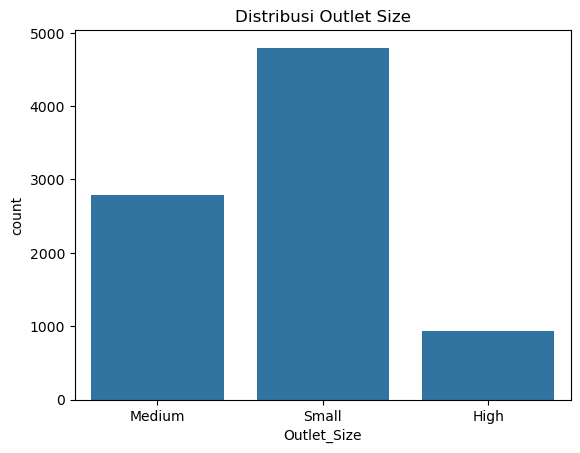

In [43]:
sns.countplot(x=df["Outlet_Size"])
plt.title("Distribusi Outlet Size")
plt.show()

ini menunjukkan bahwa outlet berukuran Small mendominasi jumlah data, diikuti oleh Medium, sementara High memiliki jumlah paling sedikit. Ketimpangan ini menunjukkan bahwa sebagian besar outlet pada dataset beroperasi dalam skala kecil, yang berpotensi memengaruhi pola penjualan dan perlu diperhatikan pada tahap pemodelan.

***Analisi Bivariate dengan target***

Pada EDA bivariate, pemilihan jenis visualisasi disesuaikan dengan tipe data yang dianalisis.  
Untuk **dua variabel numerik**, digunakan **scatter plot** karena mampu menunjukkan pola hubungan, arah korelasi, dan sebaran data antar variabel secara langsung.  

Sementara itu, untuk kombinasi variabel **kategorik dan numerik**, digunakan **boxplot** karena efektif dalam membandingkan distribusi nilai numerik pada setiap kategori, termasuk median, variasi data, serta keberadaan outlier.  

Dengan demikian, scatter plot dan boxplot dipilih agar hubungan antar variabel dapat dianalisis secara lebih informatif dan sesuai dengan karakteristik datanya.


1. Item MRP vs Sales

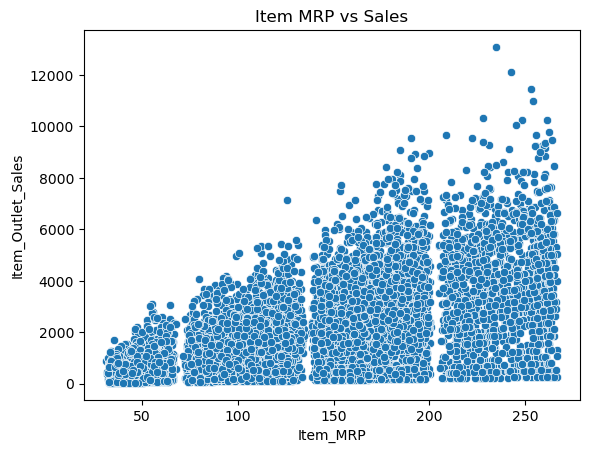

In [44]:
sns.scatterplot(x="Item_MRP", y="Item_Outlet_Sales", data=df)
plt.title("Item MRP vs Sales")
plt.show()

ini menunjukkan bahwa menunjukkan korelasi positif antara Item_MRP dan Item_Outlet_Sales, di mana produk dengan harga lebih tinggi cenderung memiliki nilai penjualan yang lebih besar. Namun, penyebaran data yang cukup lebar pada setiap rentang harga mengindikasikan bahwa harga bukan satu-satunya faktor penentu penjualan.

2. Item_Visibility vs Sales

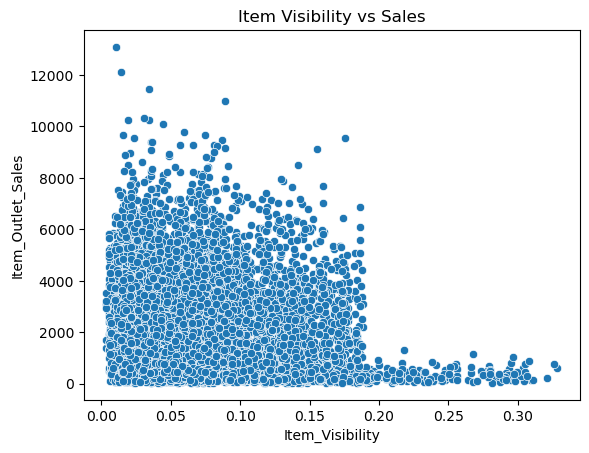

In [45]:
sns.scatterplot(x="Item_Visibility", y="Item_Outlet_Sales", data=df)
plt.title("Item Visibility vs Sales")
plt.show()

ini menunjukkan bahwa kecenderungan hubungan negatif antara Item_Visibility dan Item_Outlet_Sales. Produk dengan visibilitas yang lebih rendah justru sering memiliki penjualan yang lebih tinggi, sedangkan visibilitas tinggi tidak selalu diikuti oleh peningkatan penjualan. Hal ini mengindikasikan bahwa tingginya visibilitas tidak menjamin performa penjualan yang lebih baik.

3. Outlet Age vs Sales

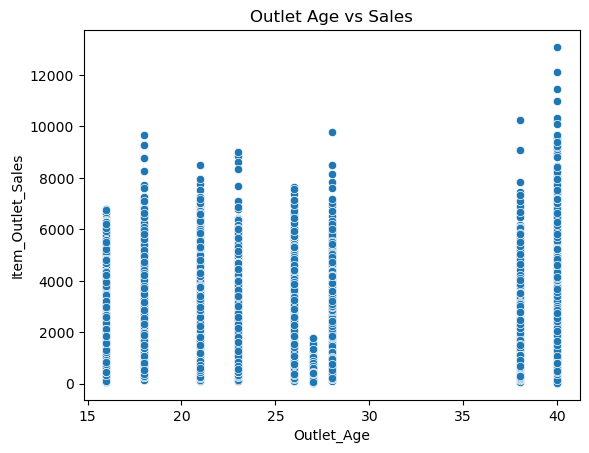

In [46]:
sns.scatterplot(x="Outlet_Age", y="Item_Outlet_Sales", data=df)
plt.title("Outlet Age vs Sales")
plt.show()

ini menunjukkan bahwa Outlet_Age membentuk pola diskret, menandakan bahwa umur outlet bersifat kategori numerik. Tidak terlihat hubungan linier yang kuat antara umur outlet dan penjualan, meskipun outlet yang lebih tua cenderung memiliki sebaran penjualan yang lebih luas dibandingkan outlet yang lebih muda.

4. Item Type vs Sales

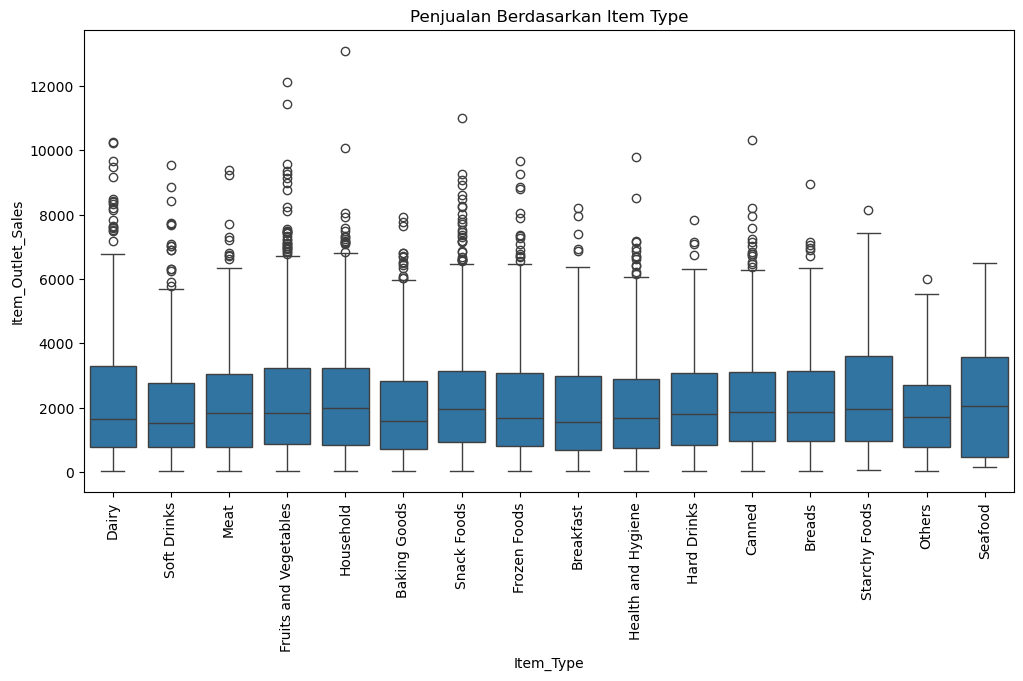

In [47]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Item_Type", y="Item_Outlet_Sales", data=df)
plt.xticks(rotation=90)
plt.title("Penjualan Berdasarkan Item Type")
plt.show()

ini menunjukkan bahwa median penjualan relatif serupa di hampir seluruh *Item Type*, namun terdapat variasi distribusi dan jumlah outlier pada masing-masing kategori. Beberapa tipe produk memiliki sebaran penjualan yang lebih lebar, mengindikasikan perbedaan performa penjualan antar produk meskipun secara umum tidak terdapat perbedaan median yang sangat ekstrem.

5. Outlet Type vs Sales

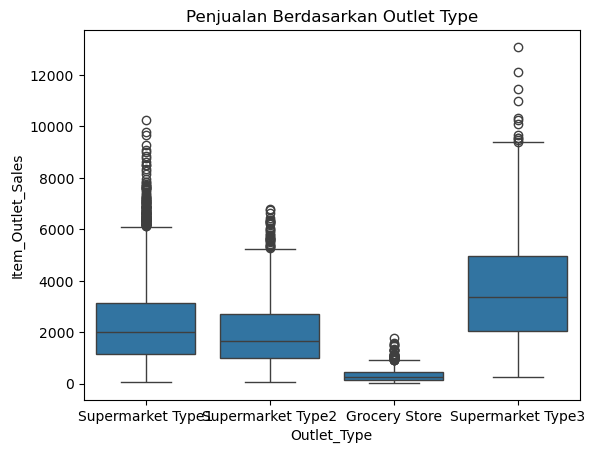

In [48]:
sns.boxplot(x="Outlet_Type", y="Item_Outlet_Sales", data=df)
plt.title("Penjualan Berdasarkan Outlet Type")
plt.show()

Terlihat perbedaan distribusi penjualan yang cukup jelas antar *Outlet Type*. Supermarket Type3 memiliki median penjualan tertinggi, diikuti oleh Supermarket Type1, sedangkan Grocery Store cenderung memiliki penjualan yang paling rendah. Hal ini menunjukkan bahwa tipe outlet merupakan faktor penting yang memengaruhi tingkat penjualan.

6. Outlet Size vs Sales

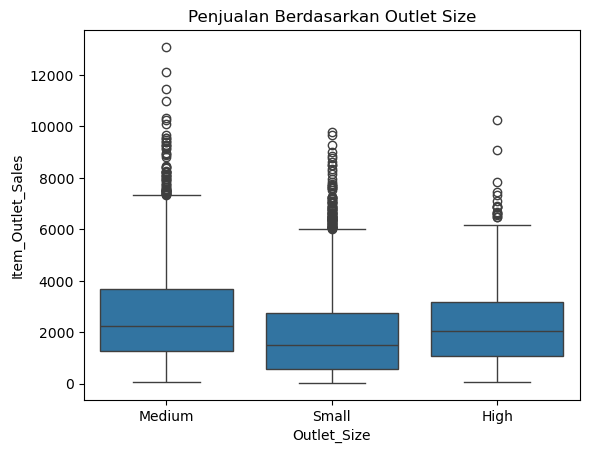

In [49]:
sns.boxplot(x="Outlet_Size", y="Item_Outlet_Sales", data=df)
plt.title("Penjualan Berdasarkan Outlet Size")
plt.show()

ini memperlihatkan bahwa outlet berukuran Medium dan High cenderung memiliki median penjualan lebih tinggi dibandingkan outlet berukuran Small. Meskipun demikian, distribusi penjualan pada masing-masing ukuran outlet masih menunjukkan tumpang tindih, sehingga ukuran outlet tetap perlu dikombinasikan dengan variabel lain dalam pemodelan.

7. Outlet Location Type vs Sales

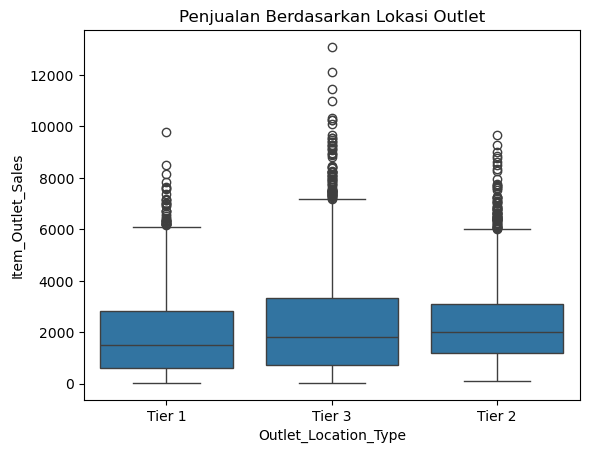

In [50]:
sns.boxplot(x="Outlet_Location_Type", y="Item_Outlet_Sales", data=df)
plt.title("Penjualan Berdasarkan Lokasi Outlet")
plt.show()

Terlihat bahwa Tier 3 memiliki distribusi penjualan yang cenderung lebih tinggi dibandingkan Tier 1 dan Tier 2. Selain itu, sebaran data di Tier 3 lebih luas, mengindikasikan adanya variasi penjualan yang lebih besar. Temuan ini menunjukkan bahwa lokasi outlet dapat berperan penting dalam memengaruhi performa penjualan.

8. Item Fat Content VS Sales

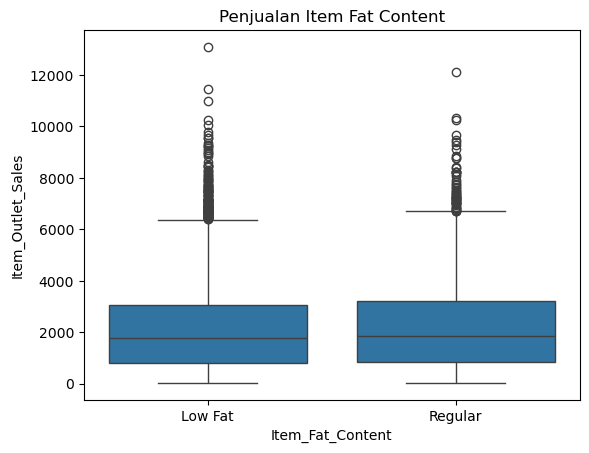

In [51]:
sns.boxplot(x="Item_Fat_Content", y="Item_Outlet_Sales", data=df)
plt.title("Penjualan Item Fat Content")
plt.show()

ini memperlihatkan bahwa kategori Regular dan Low Fat memiliki pola distribusi penjualan yang hampir mirip. Kedua kategori memiliki rentang penjualan yang lebar serta outlier pada nilai penjualan tinggi. Hal ini mengindikasikan bahwa jenis lemak pada produk tidak memberikan perbedaan signifikan terhadap total penjualan.

***Korelasi Numerik***

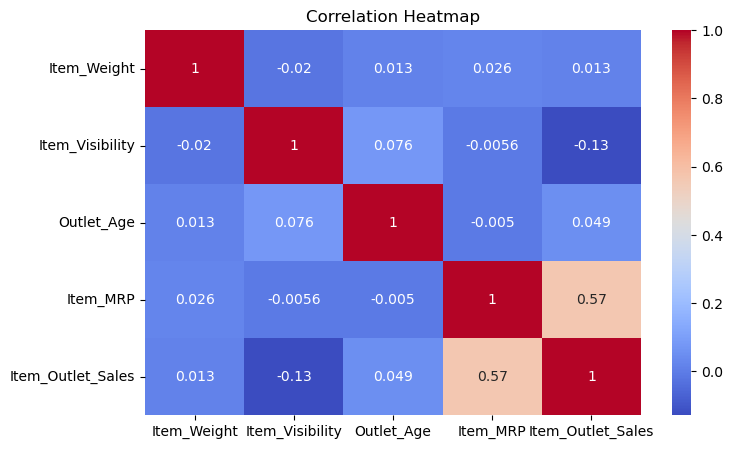

In [52]:
numeric_df = df[["Item_Weight", "Item_Visibility","Outlet_Age", "Item_MRP", "Item_Outlet_Sales"]]

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Analisis korelasi menunjukkan bahwa **Item_MRP** memiliki korelasi positif paling kuat terhadap *Item_Outlet_Sales*, menandakan harga produk berperan penting dalam menentukan nilai penjualan.  Sementara itu, **Item_Visibility** menunjukkan korelasi negatif yang lemah terhadap penjualan, yang mengindikasikan bahwa visibilitas yang lebih tinggi tidak selalu meningkatkan penjualan.  Variabel numerik lainnya seperti **Item_Weight** dan **Outlet_Age** memiliki korelasi yang relatif rendah terhadap target, sehingga kemungkinan berperan sebagai variabel pendukung dalam pemodelan.

***Kesimpulan Exploratory Data Analysis (EDA)***

Berdasarkan hasil Exploratory Data Analysis (EDA) yang telah dilakukan, dapat disimpulkan bahwa dataset BigMart memiliki karakteristik data yang beragam, baik dari sisi variabel numerik maupun kategorikal, serta menunjukkan beberapa pola penting yang memengaruhi *Item_Outlet_Sales* sebagai variabel target.

**Poin-Poin Utama Hasil EDA**

1. **Distribusi Variabel Target (Item_Outlet_Sales)**  
   * Distribusi penjualan bersifat **right-skewed**, di mana sebagian besar produk memiliki nilai penjualan rendah hingga menengah.
   * Terdapat **outlier pada nilai penjualan tinggi**, namun masih logis secara bisnis sehingga tidak dihapus.

2. **Variabel Numerik (Univariate Analysis)**  
   * **Item_Weight** memiliki distribusi relatif merata tanpa outlier ekstrem.  
   * **Item_Visibility** cenderung skewed ke kanan, dengan konsentrasi nilai pada visibilitas rendah.
   * **Item_MRP** menunjukkan beberapa cluster harga, mengindikasikan segmentasi harga produk.
   * **Outlet_Age** bersifat diskrit dan tidak menunjukkan outlier yang tidak wajar.

3. **Variabel Kategorikal (Univariate Analysis)**  
   * Produk **Low Fat** lebih dominan dibandingkan Regular.
   * Item dengan kategori **Fruits and Vegetables** serta **Snack Foods** paling banyak dijual.
   * Outlet dengan tipe **Supermarket Type1** mendominasi jumlah data.
   * Mayoritas outlet berlokasi di **Tier 2 dan Tier 3**, serta berukuran **Small**.

4. **Hubungan Variabel Numerik terhadap Penjualan (Bivariate Analysis)**  
   * **Item_MRP** menunjukkan **hubungan positif yang kuat** terhadap penjualan, menjadikannya variabel paling berpengaruh.
   * **Item_Visibility** memiliki hubungan negatif yang lemah dengan penjualan.
   * **Outlet_Age** tidak menunjukkan korelasi yang signifikan terhadap penjualan.

5. **Hubungan Variabel Kategorikal terhadap Penjualan**  
   * Penjualan bervariasi antar **Item_Type**, menunjukkan bahwa tipe produk memengaruhi performa penjualan.
   * **Outlet_Type** dan **Outlet_Size** menunjukkan perbedaan median penjualan yang jelas, di mana outlet tertentu memiliki performa lebih baik.
   * Outlet dengan **Location Type Tier 3** cenderung menghasilkan penjualan lebih tinggi.
   * **Item_Fat_Content** memiliki pengaruh terhadap penjualan, namun tidak signifikan dibandingkan variabel lain.

6. **Korelasi Antar Variabel Numerik**  
   * **Item_MRP** memiliki korelasi paling kuat terhadap *Item_Outlet_Sales*.
   * Variabel numerik lainnya memiliki korelasi rendah, sehingga berperan sebagai variabel pendukung.

Dari hasil EDA ini 5 model yang akan kita gunakan:

1. **Linear Regression**  
   Linear Regression digunakan sebagai **baseline model** untuk memberikan gambaran performa dasar. Model ini sederhana dan menjadi pembanding awal terhadap model lainnya yang lebih kompleks.

2. **Ridge Regression**  
   Ridge Regression dipilih untuk menangani potensi **multikolinearitas** antar variabel numerik serta hasil encoding variabel kategorikal. Regularisasi L2 membantu menstabilkan koefisien dan meningkatkan generalisasi model.

3. **Lasso Regression**  
   Lasso Regression digunakan karena memiliki kemampuan **feature selection** melalui regularisasi L1. Model ini membantu mengidentifikasi fitur-fitur yang paling berpengaruh terhadap penjualan dan mengurangi kompleksitas model.

4. **Decision Tree Regressor**  
   Decision Tree Regressor dipilih karena mampu menangani **hubungan non-linear** dan interaksi antar fitur tanpa asumsi distribusi data. Model ini juga relatif robust terhadap outlier yang masih valid secara bisnis.

5. **Random Forest Regressor**  
   Random Forest Regressor digunakan untuk meningkatkan performa dibandingkan Decision Tree tunggal. Dengan metode ensemble, model ini mampu mengurangi overfitting, meningkatkan stabilitas prediksi, dan menangkap pola kompleks dalam data BigMart.


# **6. Feature Engineering**

**Encoding**

Ubah variabel kategorik jadi Numerik

1. **Binary Encoding**
   - Item_Fat_Content  
   Dikodekan menjadi nilai biner karena hanya memiliki dua kategori utama, yaitu *Low Fat* dan *Regular*. Pendekatan ini sederhana dan tidak menambah dimensi data.

2. **Label Encoding**
   - Outlet_Size  
     Dikodekan secara ordinal (*Small = 0, Medium = 1, Large = 2*) karena memiliki urutan ukuran yang jelas.
   - Outlet_Location_Type  
     Dikodekan menjadi label numerik karena jumlah kategorinya sedikit dan model yang digunakan mampu menangani nilai kategorikal numerik.
   - Outlet_Type  
     Dikodekan menggunakan label numerik karena hanya berfungsi sebagai pembeda jenis outlet.

3. **One-Hot Encoding**
   - Item_Type  
   Menggunakan One-Hot Encoding karena memiliki banyak kategori dan tidak memiliki hubungan ordinal antar kategori. Metode ini mencegah asumsi urutan yang dapat menimbulkan bias pada model.


In [53]:
#Label encoding di pake saat kategorinya punya urutan (Rangking alami)
from sklearn.preprocessing import LabelEncoder
label_encoding = LabelEncoder()

df['Outlet_Size'] = label_encoding.fit_transform(df['Outlet_Size'])
df['Outlet_Location_Type'] = label_encoding.fit_transform(df['Outlet_Location_Type'])
df['Outlet_Type'] = label_encoding.fit_transform(df['Outlet_Type'])

In [54]:
# Binary Encoding? Lebih ke manual encoding sih ini
df_encode = {'Item_Fat_Content' : {'Low Fat' : 1, 'Regular' : 0}}
df = df.replace(df_encode)

In [55]:
# One hot Encoding di pakai saat kek punya banyak tipe kategori (macam tipe kerjaan)
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
df_type_enc = pd.DataFrame(enc.fit_transform(df[['Item_Type']]).toarray(),columns=enc.get_feature_names_out())

# enc.get_feature_names_out() = memberi nama kolom hasil encoding sesuai kategori asliny dia

#ngatur ulang indexny biar sejajar kalau di gabung
df = df.reset_index()

#gabungin df asli dan df hasil encode
df = pd.concat([df, df_type_enc], axis = 1)

In [56]:
df.head()

,index,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,0,9.30,1,0.016047,Dairy,249.8092,1,0,1,3735.1380,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,5.92,0,0.019278,Soft Drinks,48.2692,1,2,2,443.4228,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,17.50,1,0.016760,Meat,141.6180,1,0,1,2097.2700,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3,19.20,0,0.022861,Fruits and Vegetables,182.0950,2,2,0,732.3800,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,8.93,1,0.006590,Household,53.8614,0,2,1,994.7052,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
#Drop item type yg masih kategotik
df = df.drop(columns=['Item_Type'])

In [58]:
df.head()

,index,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,0,9.30,1,0.016047,249.8092,1,0,1,3735.1380,26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,5.92,0,0.019278,48.2692,1,2,2,443.4228,16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,17.50,1,0.016760,141.6180,1,0,1,2097.2700,26,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3,19.20,0,0.022861,182.0950,2,2,0,732.3800,27,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,8.93,1,0.006590,53.8614,0,2,1,994.7052,38,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


**Data Normalization**

Pada tahap ini dilakukan proses normalisasi data untuk menstandarkan skala setiap fitur numerik.
Karena setiap kolom memiliki rentang nilai yang berbeda-beda, scaling sangat penting untuk:

Meningkatkan performa model machine learning

Menghindari bias pada fitur yang memiliki nilai besar.

Membuat data lebih stabil, terutama jika terdapat outlier.

Jenis scaler yang digunakan menyesuaikan karakteristik tiap fitur:

1. RobustScaler

Digunakan jika data masih memiliki banyak outlier, karena scaler ini menggunakan median dan IQR (Interquartile Range) sehingga lebih tahan terhadap nilai ekstrem.
→ Dipakai untuk Item_Visibility karena distribusinya sangat skewed.

2. MinMaxScaler

Mengubah rentang nilai menjadi 0–1.
Cocok untuk fitur dengan distribusi normal atau semi-normal.
→ Dipakai untuk Item_MRP yang memiliki range harga yang cukup besar.

3. StandardScaler

Mengubah data menjadi mean = 0 dan std = 1.
Cocok untuk fitur yang akan digunakan pada model yang peka terhadap skala global.
→ Dipakai untuk Item_Weight dan Outlet_Age.

In [59]:
#Robust scaler di pakai kalau data nya masih ga normal
from sklearn.preprocessing import RobustScaler
x = df['Item_Visibility']
x = (np.array(x)).reshape(-1,1)
rob_scaler = RobustScaler()
rob_scaler.fit(x)

rob_scaler_res = rob_scaler.transform(x)

In [60]:
rob_scaler_res[0:5]

array([[-0.62484055],
       [-0.57631951],
       [-0.61413629],
       [-0.52251191],
       [-0.76687242]])

In [61]:
from sklearn.preprocessing import MinMaxScaler
x = df['Item_MRP']
x = (np.array(x)).reshape(-1,1)
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(x)
min_max_res = min_max_scaler.transform(x)

In [62]:
min_max_res[0:5]

array([[0.92750715],
       [0.0720684 ],
       [0.46828841],
       [0.64009348],
       [0.09580456]])

In [63]:
from sklearn.preprocessing import StandardScaler
x = df['Item_Weight']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)
std_scaler_res = std_scaler.transform(x)

In [64]:
std_scaler_res[0:5]

array([[-0.7697559 ],
       [-1.49746111],
       [ 0.99568277],
       [ 1.36168835],
       [-0.84941594]])

In [65]:
x = df['Outlet_Age']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)
std_scaler_res1 = std_scaler.transform(x)

In [66]:
std_scaler_res1[0:5]

array([[-0.13954076],
       [-1.33410274],
       [-0.13954076],
       [-0.02008456],
       [ 1.29393362]])

**Setelah itu hasil dari Normalization kita masukin ke data frame**

In [67]:
df['Item_Visibility_scaled'] = rob_scaler_res
df['Item_MRP_scaled'] = min_max_res
df['Item_Weight_scaled'] = std_scaler_res
df['Outlet_Age_scaled'] = std_scaler_res1

**drop yang belum di normalization**

In [68]:
df = df.drop(['Item_Visibility', 'Item_MRP', 'Item_Weight', 'Outlet_Age'], axis=1)


In [69]:
df.head()

,index,Item_Fat_Content,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,...,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Item_Visibility_scaled,Item_MRP_scaled,Item_Weight_scaled,Outlet_Age_scaled
0,0,1,1,0,1,3735.1380,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.624841,0.927507,-0.769756,-0.139541
1,1,0,1,2,2,443.4228,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-0.576320,0.072068,-1.497461,-1.334103
2,2,1,1,0,1,2097.2700,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,-0.614136,0.468288,0.995683,-0.139541
3,3,0,2,2,0,732.3800,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.522512,0.640093,1.361688,-0.020085
4,4,1,0,2,1,994.7052,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.766872,0.095805,-0.849416,1.293934


# **6. Modelling**

**Split data**

In [70]:
from sklearn.model_selection import train_test_split

X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)


(6818, 25) (1705, 25)


In [71]:
# Function untuk modelling
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np


**Baseline Modelling**

Beberapa model regresi digunakan untuk dibandingkan performanya, terdiri dari model linear, regularisasi, dan model berbasis tree.  
Evaluasi dilakukan menggunakan metrik **RMSE** dan **R² Score**.


In [72]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'R2 Score': r2
    })

results_df = pd.DataFrame(results).sort_values(by='RMSE')
results_df


,Model,RMSE,R2 Score
4,Random Forest,1062.559195,0.584605
1,Ridge Regression,1144.451625,0.518107
2,Lasso Regression,1144.476784,0.518086
0,Linear Regression,1144.477883,0.518085
3,Decision Tree,1496.218044,0.176345


**Dari lima model yang diuji, **Random Forest Regressor** memberikan performa terbaik berdasarkan nilai RMSE dan R² Score. Oleh karena itu, model ini dipilih untuk tahap selanjutnya yaitu hyperparameter tuning**

yang terbaik adalah yang score RMSE nya paling rendah dan R2 nya paling tinggi


# **Hyperparameter Tuning**

Setelah dilakukan baseline modelling, model dengan performa terbaik yaitu **Random Forest Regressor** dipilih untuk dilakukan hyperparameter tuning.  
Tujuan dari tahap ini adalah untuk mengoptimalkan kombinasi parameter model sehingga diperoleh performa yang lebih baik serta mengurangi risiko overfitting.

Metode tuning yang digunakan adalah **GridSearchCV** dengan cross-validation.

Grid Search dipilih karena mampu mengevaluasi seluruh kombinasi hyperparameter secara sistematis dan menghasilkan model dengan performa paling optimal.


In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [74]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [75]:
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [76]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_tuned = best_rf.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"RMSE (After Tuning): {rmse_tuned}")
print(f"R2 Score (After Tuning): {r2_tuned}")


RMSE (After Tuning): 1033.9495197499596
R2 Score (After Tuning): 0.6066727803511437


**Evaluasi Hyperparameter Tuning**

Hasil evaluasi menunjukkan bahwa Random Forest Regressor setelah dilakukan hyperparameter tuning mengalami peningkatan performa dibandingkan model baseline, ditunjukkan oleh penurunan nilai RMSE dan peningkatan nilai R² Score.

Hal ini membuktikan bahwa pemilihan kombinasi hyperparameter yang optimal dapat meningkatkan kemampuan generalisasi model.


# **7. Features Important**

Feature importance digunakan untuk mengetahui variabel mana yang paling berpengaruh terhadap target *Item_Outlet_Sales*.  
Analisis ini membantu memahami pola data, meningkatkan interpretabilitas model, serta memastikan model tidak hanya akurat tetapi juga masuk akal secara bisnis.

Feature importance diambil dari model berbasis pohon (*tree-based models*) karena model ini mampu mengukur kontribusi setiap fitur terhadap keputusan prediksi.

In [77]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# train model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

# ambil feature importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance.head(10)


,Feature,Importance
22,Item_MRP_scaled,0.412687
4,Outlet_Type,0.234944
0,index,0.083164
21,Item_Visibility_scaled,0.074835
23,Item_Weight_scaled,0.060566
24,Outlet_Age_scaled,0.055742
3,Outlet_Location_Type,0.007414
1,Item_Fat_Content,0.007160
2,Outlet_Size,0.007130
11,Item_Type_Fruits and Vegetables,0.006563


Berdasarkan hasil feature importance dari model Random Forest, variabel yang paling berpengaruh terhadap *Item_Outlet_Sales* adalah **Item_MRP_scaled** dengan nilai importance paling tinggi. Hal ini menunjukkan bahwa harga produk merupakan faktor utama yang memengaruhi besarnya penjualan pada outlet.

Selanjutnya, **Outlet_Type** juga memiliki kontribusi yang besar, yang mengindikasikan bahwa jenis outlet (misalnya supermarket atau grocery store) berpengaruh signifikan terhadap performa penjualan. Variabel **Item_Visibility_scaled** dan **Item_Weight_scaled** turut memberikan kontribusi, meskipun pengaruhnya tidak sebesar harga produk.

Variabel lain seperti **Outlet_Age_scaled**, **Outlet_Location_Type**, **Item_Fat_Content**, dan **Outlet_Size** memiliki nilai importance yang relatif kecil. Hal ini menunjukkan bahwa meskipun variabel-variabel tersebut tetap relevan, kontribusinya terhadap prediksi penjualan tidak dominan dibandingkan variabel utama.

Secara keseluruhan, hasil ini konsisten dengan temuan pada tahap Exploratory Data Analysis (EDA), di mana *Item_MRP* dan karakteristik outlet menunjukkan hubungan yang kuat dengan penjualan. Feature importance ini memperkuat justifikasi pemilihan model berbasis pohon serta penggunaan variabel numerik dan kategorikal yang telah diencoding dalam proses pemodelan.


# **Conclusion**

Berdasarkan seluruh tahapan analisis yang telah dilakukan dalam penelitian ini, dapat disimpulkan bahwa penjualan produk (*Item_Outlet_Sales*) pada BigMart dipengaruhi secara signifikan oleh kombinasi karakteristik produk dan karakteristik outlet. Proses penelitian diawali dengan tahap *data understanding* dan *data cleaning* yang bertujuan untuk memastikan kualitas data sebelum digunakan dalam analisis lebih lanjut. Pada tahap ini, dilakukan penanganan nilai hilang, perbaikan nilai nol yang tidak representatif, serta penghapusan atribut identitas yang tidak memiliki kontribusi prediktif secara langsung.

Hasil *Exploratory Data Analysis (EDA)* menunjukkan bahwa variabel numerik *Item_MRP* memiliki hubungan yang paling kuat terhadap penjualan, di mana peningkatan harga produk cenderung diikuti oleh peningkatan nilai *Item_Outlet_Sales*. Selain itu, variabel *Item_Visibility* dan *Outlet_Age* memperlihatkan pola hubungan non-linear terhadap penjualan. Dari sisi variabel kategorikal, perbedaan tipe outlet, ukuran outlet, dan lokasi outlet menghasilkan distribusi penjualan yang berbeda secara signifikan, yang mengindikasikan bahwa performa penjualan sangat dipengaruhi oleh karakteristik fisik dan geografis outlet.

Pada tahap pemodelan, beberapa algoritma regresi diterapkan dan dibandingkan untuk memperoleh model dengan performa terbaik. Proses *hyperparameter tuning* dilakukan menggunakan *GridSearchCV* guna mengoptimalkan kinerja model. Model berbasis pohon (*tree-based models*) menunjukkan performa yang lebih unggul dalam menangkap hubungan kompleks antar variabel, terutama karena kemampuannya dalam menangani non-linearitas dan interaksi fitur. Hal ini diperkuat oleh hasil analisis *feature importance*, di mana *Item_MRP* menjadi variabel dengan kontribusi paling dominan terhadap prediksi penjualan, diikuti oleh variabel karakteristik outlet seperti *Outlet_Type* dan *Outlet_Age*.

Secara keseluruhan, hasil penelitian ini menunjukkan bahwa pendekatan *machine learning* mampu memberikan gambaran yang komprehensif mengenai faktor-faktor yang memengaruhi penjualan BigMart. Model yang dibangun tidak hanya memiliki performa prediksi yang baik, tetapi juga memberikan interpretasi yang selaras dengan konteks bisnis, sehingga dapat dimanfaatkan sebagai dasar pengambilan keputusan berbasis data.


# **Recommendation**

Berdasarkan hasil analisis serta kesimpulan yang telah diperoleh, beberapa rekomendasi dapat disampaikan sebagai berikut:

1. **Pengembangan dan Optimasi Model Prediksi**  
   Disarankan untuk terus menggunakan model berbasis *ensemble* atau *tree-based* karena model tersebut menunjukkan performa yang lebih baik dalam menangkap hubungan non-linear antar variabel. Selain itu, penerapan *hyperparameter tuning* secara lebih mendalam serta evaluasi berkala menggunakan data terbaru perlu dilakukan untuk memastikan stabilitas dan konsistensi performa model.

2. **Penambahan dan Pengayaan Variabel**  
   Penelitian selanjutnya disarankan untuk menambahkan variabel eksternal seperti data promosi, diskon, musiman (*seasonality*), serta tren waktu penjualan. Penambahan variabel tersebut diharapkan dapat meningkatkan kemampuan model dalam merepresentasikan kondisi bisnis secara lebih komprehensif dan meningkatkan akurasi prediksi.

3. **Strategi Penetapan Harga Berbasis Data**  
   Mengingat *Item_MRP* merupakan variabel dengan pengaruh paling signifikan terhadap penjualan, perusahaan disarankan untuk menerapkan strategi penetapan harga yang berbasis data. Penyesuaian harga dapat dilakukan dengan mempertimbangkan karakteristik produk serta tipe dan lokasi outlet guna mengoptimalkan potensi penjualan.

4. **Optimalisasi Distribusi dan Stok Produk**  
   Karakteristik outlet, seperti tipe outlet, ukuran outlet, dan lokasi outlet, perlu dijadikan dasar dalam perencanaan distribusi dan pengelolaan stok. Outlet dengan performa penjualan lebih tinggi dapat diprioritaskan dalam distribusi produk unggulan, sementara outlet dengan performa lebih rendah dapat diberikan strategi pendukung, seperti promosi atau peningkatan visibilitas produk.

5. **Implementasi Model dalam Pengambilan Keputusan Bisnis**  
   Model prediksi yang telah dikembangkan dapat diintegrasikan ke dalam sistem pendukung keputusan (*Decision Support System*). Dengan demikian, perusahaan dapat mengambil keputusan strategis terkait penjualan, distribusi, dan manajemen produk secara lebih objektif dan berbasis data.

6. **Evaluasi dan Pemeliharaan Model Secara Berkala**  
   Disarankan untuk melakukan evaluasi model secara periodik guna menyesuaikan dengan perubahan pola penjualan dan kondisi pasar. Proses *retraining* model secara berkala penting untuk menjaga relevansi dan keandalan model dalam jangka panjang.
